In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:

cols = [
    "area",
    "perimeter",
    "compactness",
    "kernel_length",
    "kernel_width",
    "asymmetry",
    "groove_length",
    "class"
]

df = pd.read_csv(
    "seeds_dataset.txt",
    sep=r"\s+",
    header=None,
    names=cols
)

df.to_csv("seeds_dataset.csv", index=False)

print(df.head())

    area  perimeter  compactness  kernel_length  kernel_width  asymmetry  \
0  15.26      14.84       0.8710          5.763         3.312      2.221   
1  14.88      14.57       0.8811          5.554         3.333      1.018   
2  14.29      14.09       0.9050          5.291         3.337      2.699   
3  13.84      13.94       0.8955          5.324         3.379      2.259   
4  16.14      14.99       0.9034          5.658         3.562      1.355   

   groove_length  class  
0          5.220      1  
1          4.956      1  
2          4.825      1  
3          4.805      1  
4          5.175      1  


In [6]:
df = pd.read_csv('seeds_dataset.csv')
# Display the first few rows of the dataset
print(df.head())

# Get summary information of the dataset
print(df.info())

# Check for missing values
print(df.isnull().sum())

# Get basic statistics of numerical columns
print(df.describe())

    area  perimeter  compactness  kernel_length  kernel_width  asymmetry  \
0  15.26      14.84       0.8710          5.763         3.312      2.221   
1  14.88      14.57       0.8811          5.554         3.333      1.018   
2  14.29      14.09       0.9050          5.291         3.337      2.699   
3  13.84      13.94       0.8955          5.324         3.379      2.259   
4  16.14      14.99       0.9034          5.658         3.562      1.355   

   groove_length  class  
0          5.220      1  
1          4.956      1  
2          4.825      1  
3          4.805      1  
4          5.175      1  
<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   area           210 non-null    float64
 1   perimeter      210 non-null    float64
 2   compactness    210 non-null    float64
 3   kernel_length  210 non-null    float64
 4   kernel_width   210 non-nu

In [7]:
# Find and count duplicate rows
duplicate_rows = df[df.duplicated()]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")

# Drop duplicate rows if necessary
df_cleaned = df.drop_duplicates()


Number of duplicate rows: 0


In [8]:
df.head()

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_length,class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [9]:
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())
print("\nDescription:")
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())
print("\nClass count:")
print(df["class"].value_counts())


Shape: (210, 8)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   area           210 non-null    float64
 1   perimeter      210 non-null    float64
 2   compactness    210 non-null    float64
 3   kernel_length  210 non-null    float64
 4   kernel_width   210 non-null    float64
 5   asymmetry      210 non-null    float64
 6   groove_length  210 non-null    float64
 7   class          210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB
None

Description:
             area   perimeter  compactness  kernel_length  kernel_width  \
count  210.000000  210.000000   210.000000     210.000000    210.000000   
mean    14.847524   14.559286     0.870999       5.628533      3.258605   
std      2.909699    1.305959     0.023629       0.443063      0.377714   
min     10.590000   12.410000     0.808100       4.899000      2.630000   

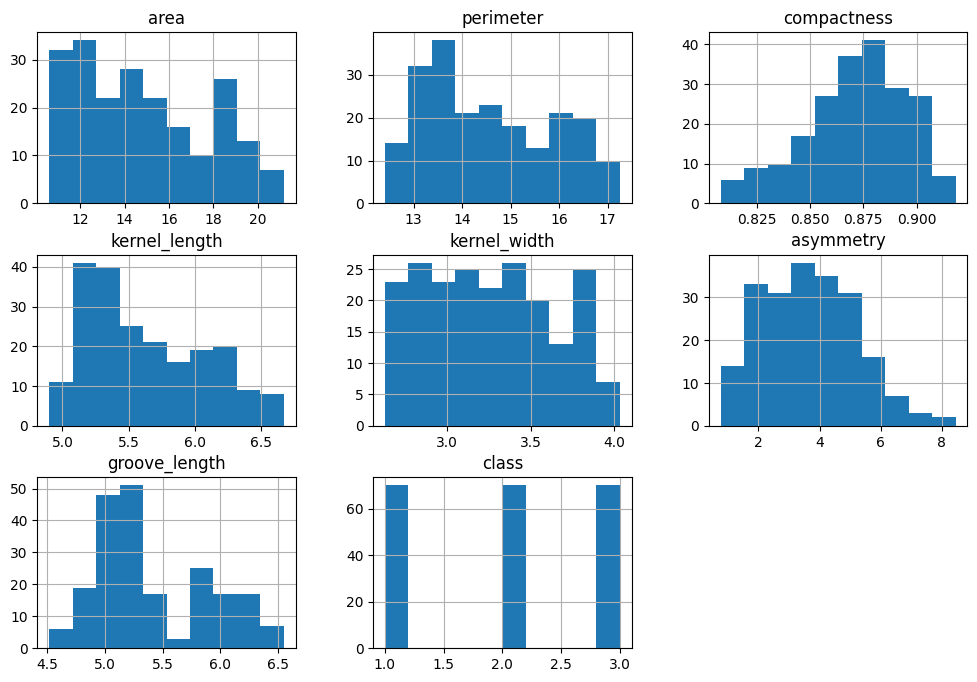

In [10]:
df.hist(figsize=(12,8))
plt.show()


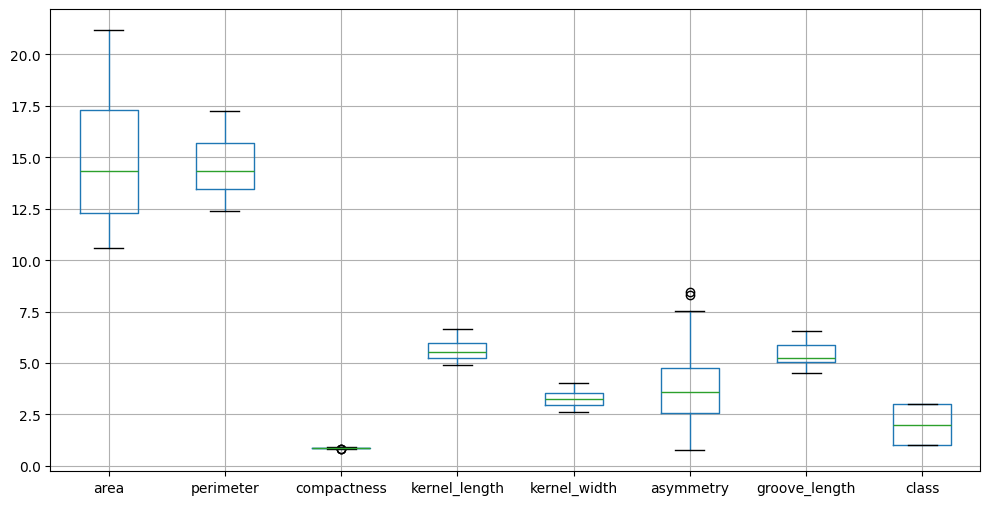

In [11]:
df.boxplot(figsize=(12,6))
plt.show()


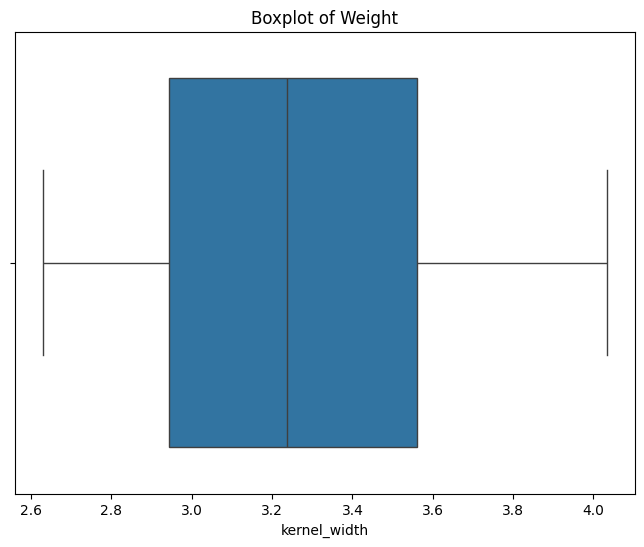

In [13]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['kernel_width'])
plt.title('Boxplot of Weight')
plt.show()

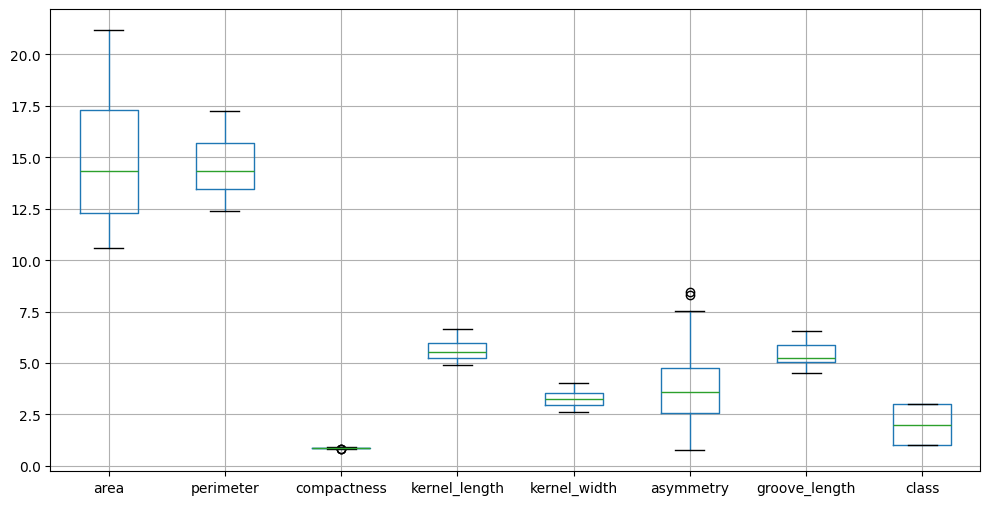

In [14]:
df.boxplot(figsize=(12,6))
plt.show()

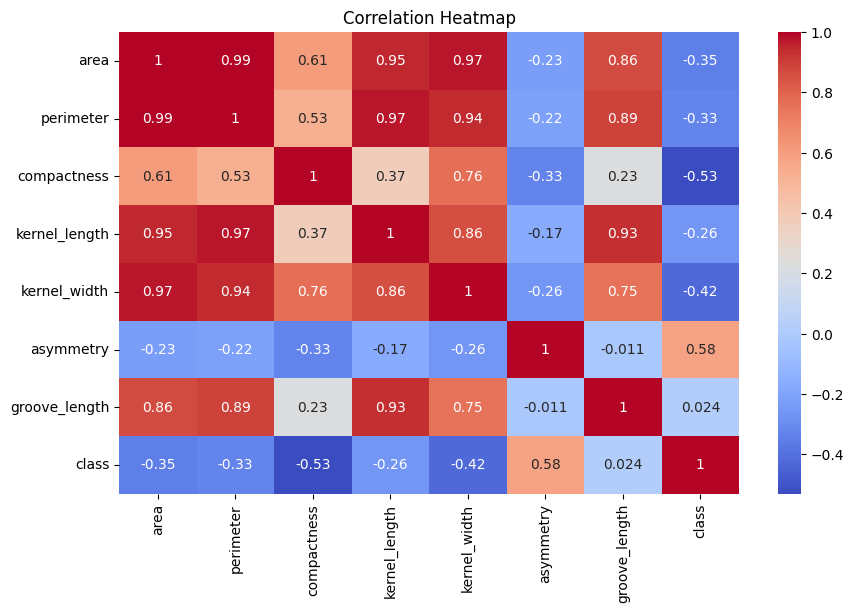

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title('Correlation Heatmap')
plt.show()


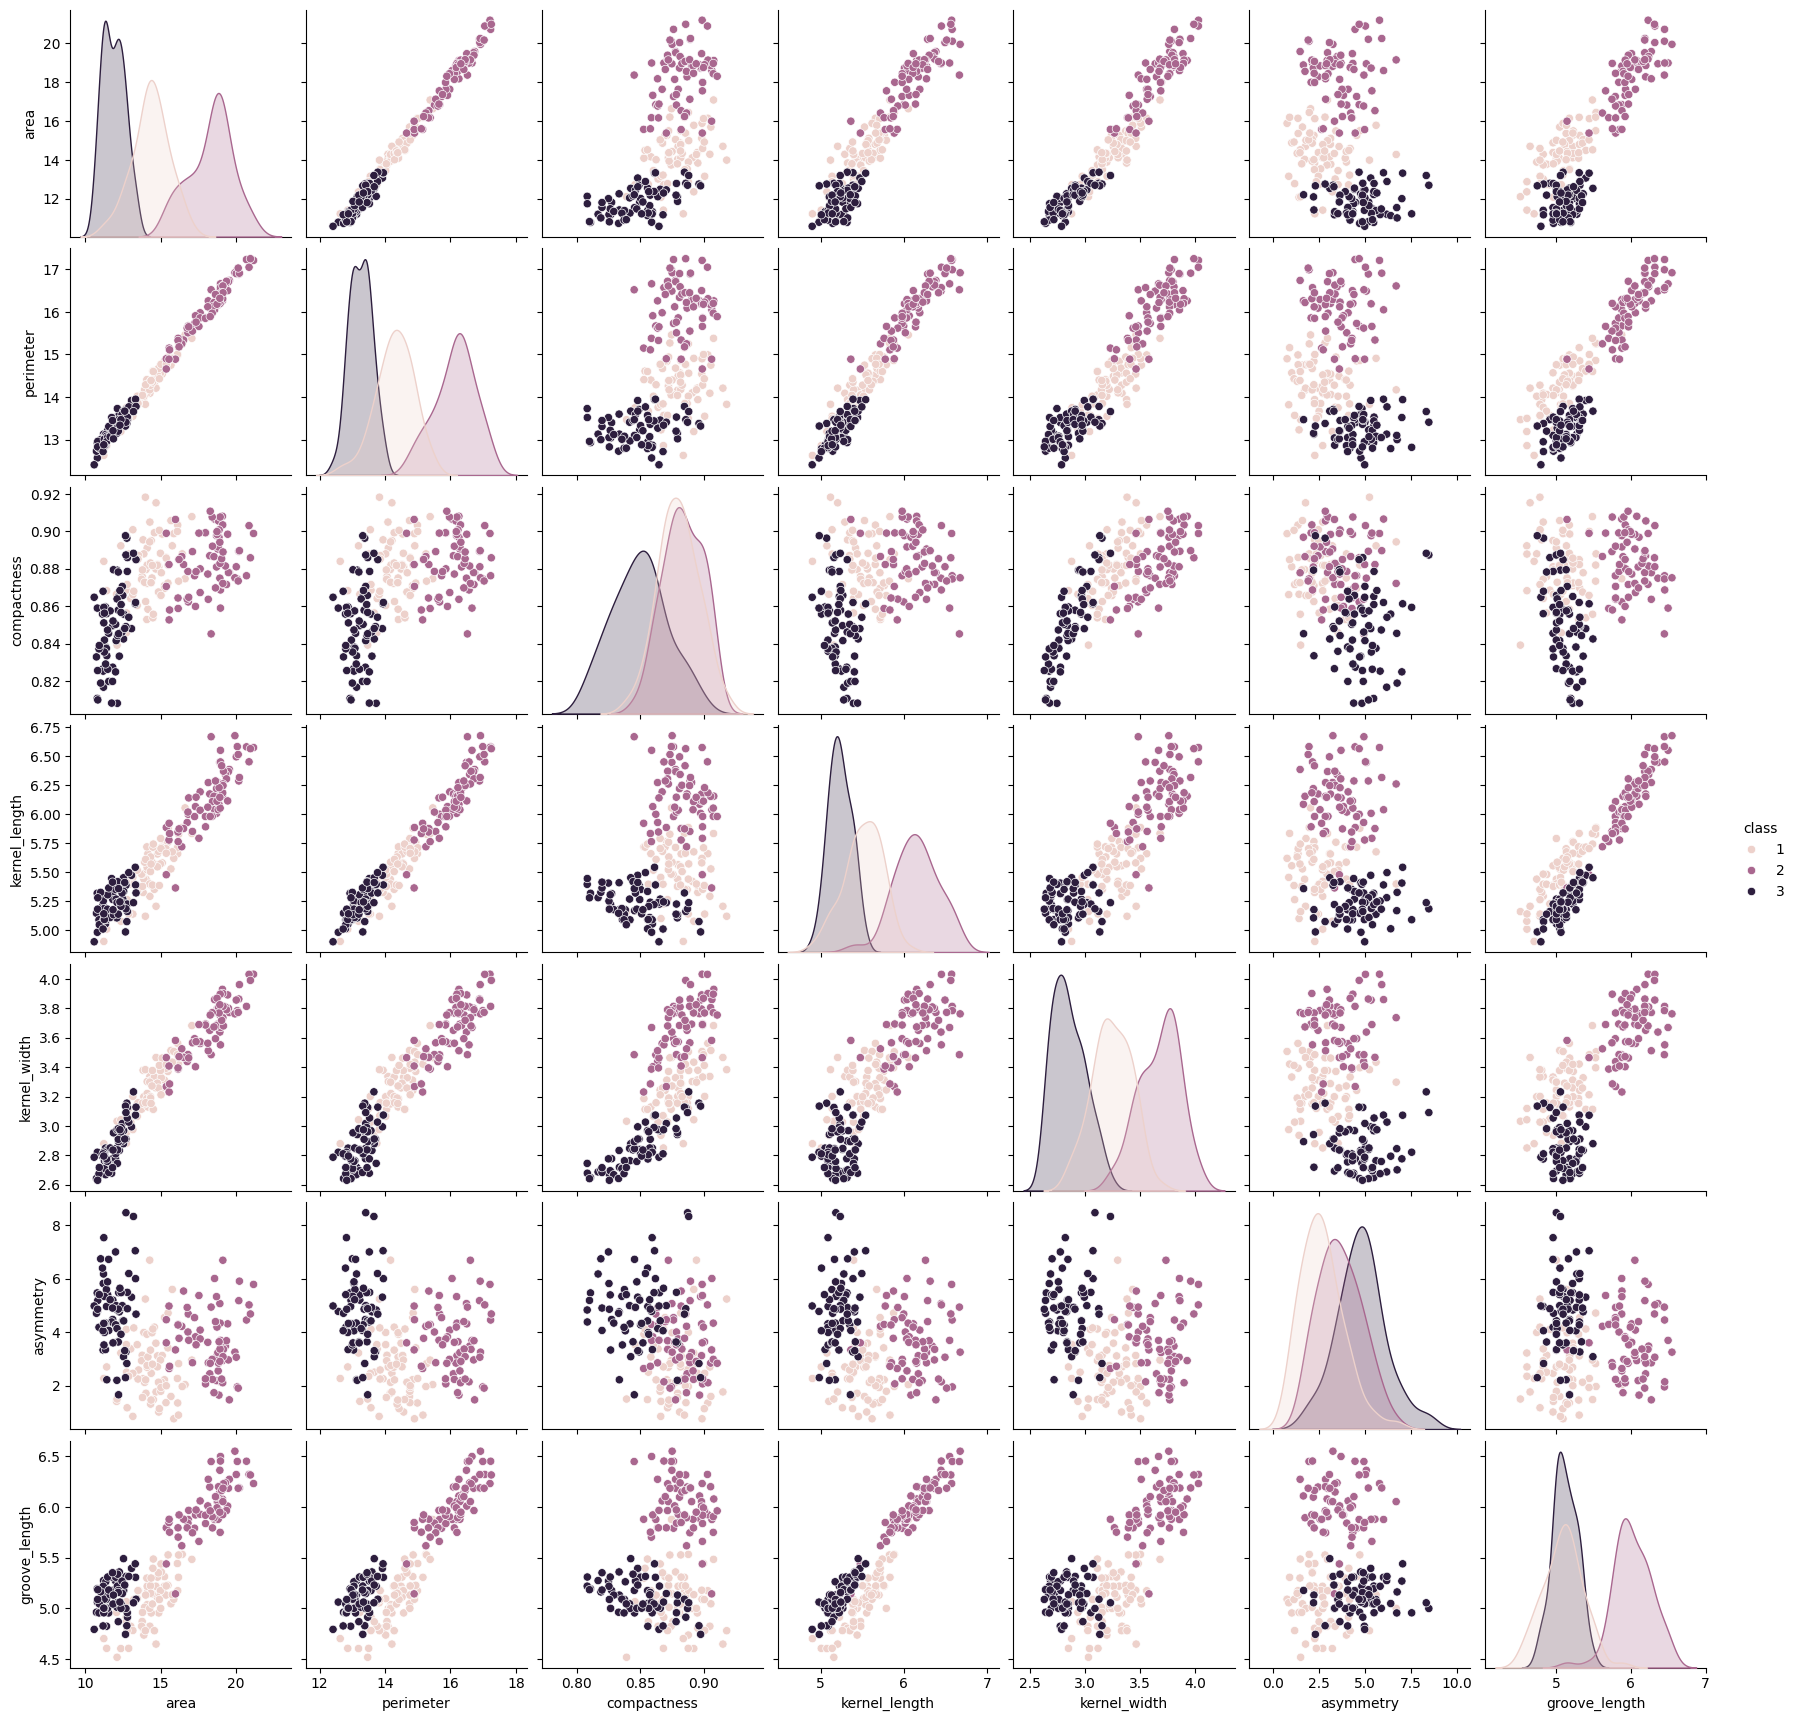

In [17]:
sns.pairplot(df, hue="class")
plt.show()


In [ ]:
# Compute correlation only for numeric columns
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

NameError: name 'df' is not defined

In [18]:
X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))
print("\nClassification Report:")
print(classification_report(y_test, pred))


Accuracy: 0.8809523809523809

Confusion Matrix:
[[ 9  0  2]
 [ 0 14  0]
 [ 3  0 14]]

Classification Report:
              precision    recall  f1-score   support

           1       0.75      0.82      0.78        11
           2       1.00      1.00      1.00        14
           3       0.88      0.82      0.85        17

    accuracy                           0.88        42
   macro avg       0.88      0.88      0.88        42
weighted avg       0.88      0.88      0.88        42

